**Виконавець:** Базилевич Олексій, група К-27
**Викладач:** Андрій Ляшко
**Варіант:** 99

**Умова задачі 1:**
Для кожної характеристики по місяцях побудувати: графік, графік з накопиченням, стовпчикову діаграму, стовпчикову діаграму з накопиченням. Графіки розташувати на одному зображенні (4 окремі фігури по 4 частки). Також побудувати кругову діаграму.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
WHITE_LIST = ['.txt', '.cpp', '.h', '.py', '.csv']
START_YEAR = 2024
START_MONTH = 9

In [3]:
df = pd.read_csv('lab1_1.csv')
df['ext'] = df['ext'].fillna('')
df['lines'] = df['lines'].fillna(0)
df = df[df['ext'].isin(WHITE_LIST)]
df = df[(df['year'] > START_YEAR) | ((df['year'] == START_YEAR) & (df['mon'] >= START_MONTH))]
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['mon'].astype(str) + '-01')

grouped = df.groupby('date').agg({'cnt': 'sum', 'size': 'sum', 'lines': 'sum'})
grouped['avg_size'] = grouped['size'] / grouped['cnt']
grouped.index = grouped.index.strftime('%Y-%m')

metrics = [
    ('cnt', 'Кількість файлів'),
    ('size', 'Сумарний розмір (байти)'),
    ('lines', 'Кількість рядків'),
    ('avg_size', 'Середній розмір (байти)')
]

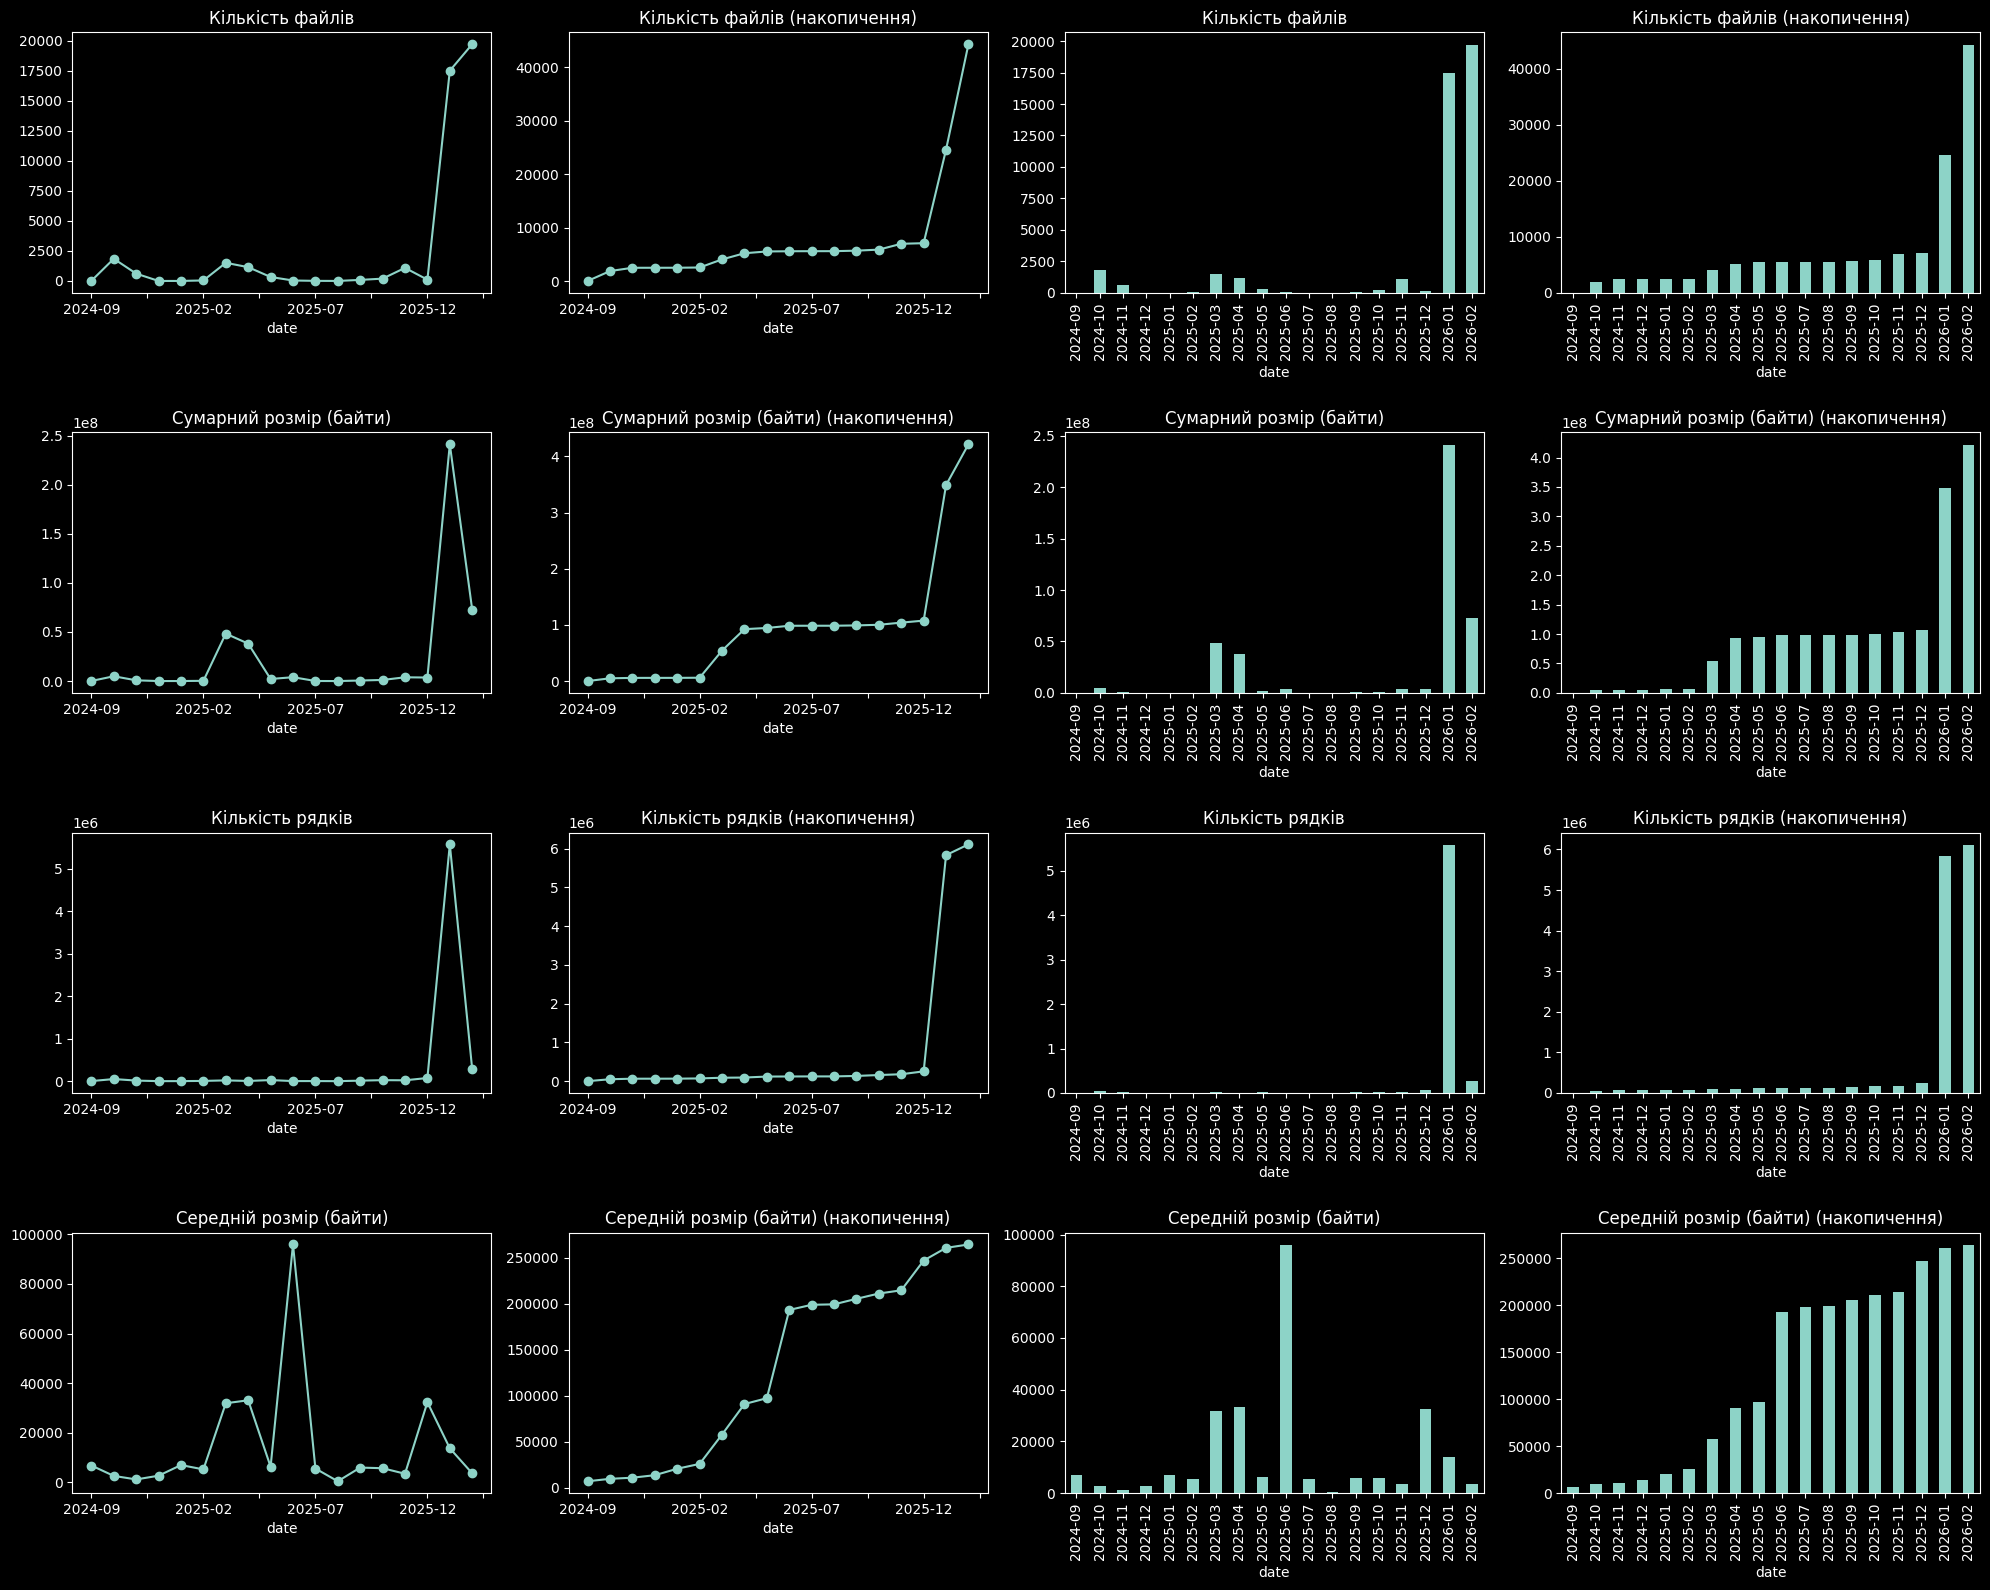

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for i, (col, title) in enumerate(metrics):
    data = grouped[col]
    data_cumsum = data.cumsum()

    data.plot(kind='line', ax=axes[i, 0], marker='o')
    axes[i, 0].set_title(title)

    data_cumsum.plot(kind='line', ax=axes[i, 1], marker='o')
    axes[i, 1].set_title(title + ' (накопичення)')

    data.plot(kind='bar', ax=axes[i, 2])
    axes[i, 2].set_title(title)

    data_cumsum.plot(kind='bar', ax=axes[i, 3])
    axes[i, 3].set_title(title + ' (накопичення)')

plt.tight_layout()
plt.savefig("16_plots.png")
plt.show()

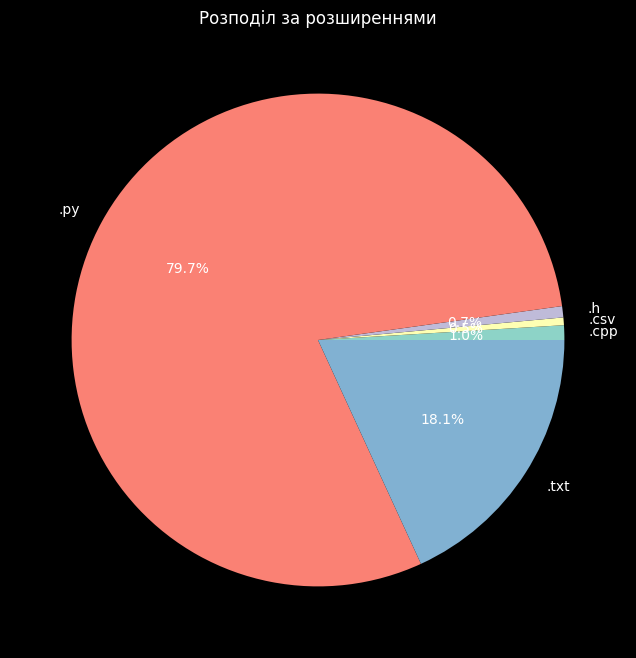

In [5]:
pie_data = df.groupby('ext')['cnt'].sum()
plt.figure(figsize=(8, 8))
pie_data.plot(kind='pie', autopct='%1.1f%%')
plt.title('Розподіл за розширеннями')
plt.ylabel('')
plt.savefig("pie_chart.png")
plt.show()